# Customer Churn Prediction using Machine Learning

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder, StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

## Load the Dataset

In [4]:
train_df = pd.read_csv("customer_churn_dataset-training-master.csv")
test_df = pd.read_csv("customer_churn_dataset-testing-master.csv")

print("Training Dataset Shape:", train_df.shape)
print("Testing Dataset Shape:", test_df.shape)

Training Dataset Shape: (440833, 12)
Testing Dataset Shape: (64374, 12)


In [5]:
train_df.head()

,CustomerID,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
0,2.0,30.0,Female,39.0,14.0,5.0,18.0,Standard,Annual,932.0,17.0,1.0
1,3.0,65.0,Female,49.0,1.0,10.0,8.0,Basic,Monthly,557.0,6.0,1.0
2,4.0,55.0,Female,14.0,4.0,6.0,18.0,Basic,Quarterly,185.0,3.0,1.0
3,5.0,58.0,Male,38.0,21.0,7.0,7.0,Standard,Monthly,396.0,29.0,1.0
4,6.0,23.0,Male,32.0,20.0,5.0,8.0,Basic,Monthly,617.0,20.0,1.0


In [6]:
train_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 440833 entries, 0 to 440832
Data columns (total 12 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   CustomerID         440832 non-null  float64
 1   Age                440832 non-null  float64
 2   Gender             440832 non-null  str    
 3   Tenure             440832 non-null  float64
 4   Usage Frequency    440832 non-null  float64
 5   Support Calls      440832 non-null  float64
 6   Payment Delay      440832 non-null  float64
 7   Subscription Type  440832 non-null  str    
 8   Contract Length    440832 non-null  str    
 9   Total Spend        440832 non-null  float64
 10  Last Interaction   440832 non-null  float64
 11  Churn              440832 non-null  float64
dtypes: float64(9), str(3)
memory usage: 40.4 MB


In [7]:
train_df.describe()

,CustomerID,Age,Tenure,Usage Frequency,Support Calls,Payment Delay,Total Spend,Last Interaction,Churn
count,440832.000000,440832.000000,440832.000000,440832.000000,440832.000000,440832.000000,440832.000000,440832.000000,440832.000000
mean,225398.667955,39.373153,31.256336,15.807494,3.604437,12.965722,631.616223,14.480868,0.567107
std,129531.918550,12.442369,17.255727,8.586242,3.070218,8.258063,240.803001,8.596208,0.495477
min,2.000000,18.000000,1.000000,1.000000,0.000000,0.000000,100.000000,1.000000,0.000000
25%,113621.750000,29.000000,16.000000,9.000000,1.000000,6.000000,480.000000,7.000000,0.000000
50%,226125.500000,39.000000,32.000000,16.000000,3.000000,12.000000,661.000000,14.000000,1.000000
75%,337739.250000,48.000000,46.000000,23.000000,6.000000,19.000000,830.000000,22.000000,1.000000
max,449999.000000,65.000000,60.000000,30.000000,10.000000,30.000000,1000.000000,30.000000,1.000000


In [8]:
train_df.isnull().sum()

CustomerID           1
Age                  1
Gender               1
Tenure               1
Usage Frequency      1
Support Calls        1
Payment Delay        1
Subscription Type    1
Contract Length      1
Total Spend          1
Last Interaction     1
Churn                1
dtype: int64

## Explore the Target Variable

In [9]:
train_df["Churn"].value_counts()

Churn
1.0    249999
0.0    190833
Name: count, dtype: int64

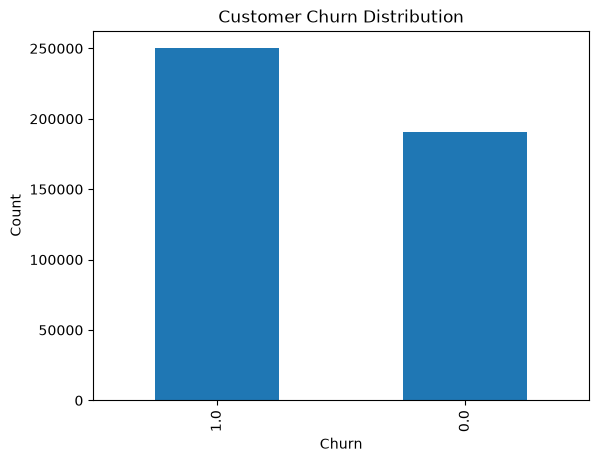

In [10]:
train_df["Churn"].value_counts().plot(kind="bar")
plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Count")
plt.show()

## Check Duplicate Records

In [41]:
print("Duplicate Rows:", train_df.duplicated().sum())

Duplicate Rows: 0


## Data Preparation

In [30]:
print(train_df["Churn"].isnull().sum())
print(test_df["Churn"].isnull().sum())

1
0


In [31]:
train_df = train_df.dropna(subset=["Churn"])

print("Missing Churn values:", train_df["Churn"].isnull().sum())

Missing Churn values: 0


In [32]:
from sklearn.preprocessing import StandardScaler

X_train = train_df.drop(["CustomerID", "Churn"], axis=1)
y_train = train_df["Churn"].astype(int)

X_test = test_df.drop(["CustomerID", "Churn"], axis=1)
y_test = test_df["Churn"].astype(int)

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("Ready for training!")

Ready for training!


## Prepare Features and Target

In [18]:
X_train = train_df.drop(["CustomerID", "Churn"], axis=1)
y_train = train_df["Churn"]

X_test = test_df.drop(["CustomerID", "Churn"], axis=1)
y_test = test_df["Churn"]

print("Training Features:", X_train.shape)
print("Testing Features:", X_test.shape)

Training Features: (440833, 10)
Testing Features: (64374, 10)


## Feature Scaling

In [19]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("Feature scaling completed.")

Feature scaling completed.


## Model Development

In [34]:
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(max_iter=1000, random_state=42)

log_model.fit(X_train, y_train)

log_pred = log_model.predict(X_test)

print("Logistic Regression model trained successfully.")

Logistic Regression model trained successfully.


In [35]:
from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(random_state=42)

dt_model.fit(X_train, y_train)

dt_pred = dt_model.predict(X_test)

print("Decision Tree model trained successfully.")

Decision Tree model trained successfully.


In [36]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

print("Random Forest model trained successfully.")

Random Forest model trained successfully.


## Model Evaluation

In [37]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest"
    ],
    "Accuracy": [
        accuracy_score(y_test, log_pred),
        accuracy_score(y_test, dt_pred),
        accuracy_score(y_test, rf_pred)
    ],
    "Precision": [
        precision_score(y_test, log_pred),
        precision_score(y_test, dt_pred),
        precision_score(y_test, rf_pred)
    ],
    "Recall": [
        recall_score(y_test, log_pred),
        recall_score(y_test, dt_pred),
        recall_score(y_test, rf_pred)
    ],
    "F1 Score": [
        f1_score(y_test, log_pred),
        f1_score(y_test, dt_pred),
        f1_score(y_test, rf_pred)
    ]
})

results = results.round(4)
results

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.5866,0.5346,0.9825,0.6925
1,Decision Tree,0.5034,0.4882,0.9987,0.6558
2,Random Forest,0.5034,0.4882,0.9987,0.6558


From the comparison, Logistic Regression performed better than the Decision Tree and Random Forest models in terms of overall accuracy and F1-score. Therefore, it was selected as the final model for customer churn prediction.

## Confusion Matrices

In [38]:
from sklearn.metrics import confusion_matrix

models = {
    "Logistic Regression": log_pred,
    "Decision Tree": dt_pred,
    "Random Forest": rf_pred
}

for name, pred in models.items():
    print(f"\n{name}")
    print(confusion_matrix(y_test, pred))


Logistic Regression
[[ 7804 26077]
 [  533 29960]]

Decision Tree
[[ 1949 31932]
 [   39 30454]]

Random Forest
[[ 1957 31924]
 [   41 30452]]


## Conclusion

Three machine learning classification models were developed to predict customer churn.

Among the implemented models, Logistic Regression achieved the best overall performance with an accuracy of **58.66%** and an F1-score of **69.25%**. Based on these results, it was selected as the most suitable model for predicting customer churn in this dataset.

This project demonstrates how machine learning can help businesses identify customers who are likely to churn, allowing them to take proactive steps to improve customer retention and reduce potential revenue loss.